In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

对比不同解码方式的rollout

In [3]:
import re
import numpy as np
from pathlib import Path
from collections import Counter

def parse_diversity_line(line):
    """
    解析单行diversity数据，提取完整信息
    示例: diversity| distinct_answer_num: 6 | all_answer_num: 8 | distinct_answer_ratio: 0.75 | best_answer_ratio: 0.38 | correct_answer_number: 1 | best_is_correct: 0 | extracted_answers: ['0', '33.33', '22', '33.33', '33.33', '36.25', '24', '42'] | majority_answer: 33.33 | ground_truth_answer: 22
    """
    # 解析基础指标
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if not match:
        return None
    
    # 提取答案列表
    answers_pattern = r'extracted_answers:\s*\[(.*?)\]'
    answers_match = re.search(answers_pattern, line)
    extracted_answers = []
    if answers_match:
        # 解析答案列表字符串
        answers_str = answers_match.group(1)
        # 处理引号内的内容
        extracted_answers = re.findall(r"'([^']*)'", answers_str)
    
    # 提取多数投票答案
    majority_pattern = r'majority_answer:\s*([^\s|]+)'
    majority_match = re.search(majority_pattern, line)
    majority_answer = majority_match.group(1) if majority_match else None
    
    # 提取真实答案
    truth_pattern = r'ground_truth_answer:\s*([^\s|]+)'
    truth_match = re.search(truth_pattern, line)
    ground_truth = truth_match.group(1) if truth_match else None
    
    return {
        'distinct_answer_num': int(match.group(1)),
        'all_answer_num': int(match.group(2)),
        'best_answer_ratio': float(match.group(3)),
        'correct_answer_number': int(match.group(4)),
        'best_is_correct': int(match.group(5)),
        'extracted_answers': extracted_answers,
        'majority_answer': majority_answer,
        'ground_truth': ground_truth
    }

def calculate_reward_metrics(answers, majority_answer, ground_truth):
    """
    计算reward accuracy和相关指标
    
    Args:
        answers: 所有rollout的答案列表
        majority_answer: 多数投票答案
        ground_truth: 真实答案
    
    Returns:
        dict: 包含各项指标
    """
    n = len(answers)
    if n == 0 or majority_answer is None or ground_truth is None:
        return {
            'reward_accuracy': 0,
            'true_positive_ratio': 0,
            'true_negative_ratio': 0,
            'false_positive_ratio': 0,
            'false_negative_ratio': 0
        }
    
    # 为每个rollout计算估计奖励和真实奖励
    tp = fp = tn = fn = 0
    
    for ans in answers:
        est_reward = 1 if ans == majority_answer else 0  # 估计奖励：是否匹配多数投票
        true_reward = 1 if ans == ground_truth else 0     # 真实奖励：是否真实正确
        
        if est_reward == 1 and true_reward == 1:
            tp += 1  # True Positive: 估计正确且真实正确
        elif est_reward == 1 and true_reward == 0:
            fp += 1  # False Positive: 估计正确但真实错误
        elif est_reward == 0 and true_reward == 1:
            fn += 1  # False Negative: 估计错误但真实正确
        elif est_reward == 0 and true_reward == 0:
            tn += 1  # True Negative: 估计错误且真实错误
    
    # 计算各项指标
    total = tp + fp + tn + fn
    
    # Reward Accuracy: 估计奖励与真实奖励一致的比例
    reward_accuracy = (tp + tn) / total if total > 0 else 0
    
    # True Positive Ratio: TP / (TP + FN)
    true_positive_ratio = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # True Negative Ratio: TN / (TN + FP)
    true_negative_ratio = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Positive Ratio: FP / (FP + TN)
    false_positive_ratio = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # False Negative Ratio: FN / (FN + TP)
    false_negative_ratio = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    return {
        'reward_accuracy': reward_accuracy,
        'true_positive_ratio': true_positive_ratio,
        'true_negative_ratio': true_negative_ratio,
        'false_positive_ratio': false_positive_ratio,
        'false_negative_ratio': false_negative_ratio,
        # 也返回原始计数以便调试
        'tp_count': tp,
        'fp_count': fp,
        'tn_count': tn,
        'fn_count': fn
    }

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    过滤掉所有rollout相同的样本（无法产生梯度）
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0,
            'good_reward_ratio': 0,
            'zero_reward_ratio': 0,
            'bad_reward_ratio': 0,
            'effective_sample_ratio': 0,  # 有效样本比例（distinct_num > 1）
            'effective_reward_accuracy': 0,  # 有效样本中的reward accuracy
            'effective_tp_ratio': 0,
            'effective_fp_ratio': 0,
            'effective_tn_ratio': 0,
            'effective_fn_ratio': 0,
            'overall_reward_accuracy': 0,  # 所有样本（包括无效）的reward accuracy（供参考）
        }
    
    n_samples = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']
    
    # 原有的指标计算
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    avg_accuracy = avg_correct_num / all_answer_num
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    # 样本类型比例
    good_reward_count = zero_reward_count = bad_reward_count = 0
    for d in data_list:
        if d['distinct_answer_num'] == 1:
            zero_reward_count += 1
        elif d['best_is_correct'] == 1:
            good_reward_count += 1
        else:
            bad_reward_count += 1
    
    # ========== 有效样本过滤 ==========
    # 有效样本：distinct_answer_num > 1（有多样性，能产生梯度）
    effective_samples = [d for d in data_list if d['distinct_answer_num'] > 1]
    effective_sample_ratio = len(effective_samples) / n_samples if n_samples > 0 else 0
    
    # 在所有样本上计算overall reward accuracy（包括无效样本）
    total_tp_all = total_fp_all = total_tn_all = total_fn_all = 0
    
    # 在有效样本上计算effective reward metrics
    total_tp_eff = total_fp_eff = total_tn_eff = total_fn_eff = 0
    
    for d in data_list:
        if 'extracted_answers' not in d or not d['majority_answer'] or not d['ground_truth']:
            continue
            
        answers = d['extracted_answers']
        majority = d['majority_answer']
        truth = d['ground_truth']
        is_effective = d['distinct_answer_num'] > 1
        
        for ans in answers:
            est_reward = 1 if ans == majority else 0
            true_reward = 1 if ans == truth else 0
            
            # 统计所有样本
            if est_reward == 1 and true_reward == 1:
                total_tp_all += 1
            elif est_reward == 1 and true_reward == 0:
                total_fp_all += 1
            elif est_reward == 0 and true_reward == 0:
                total_tn_all += 1
            elif est_reward == 0 and true_reward == 1:
                total_fn_all += 1
            
            # 只统计有效样本
            if is_effective:
                if est_reward == 1 and true_reward == 1:
                    total_tp_eff += 1
                elif est_reward == 1 and true_reward == 0:
                    total_fp_eff += 1
                elif est_reward == 0 and true_reward == 0:
                    total_tn_eff += 1
                elif est_reward == 0 and true_reward == 1:
                    total_fn_eff += 1
    
    # 计算overall指标（所有样本）
    total_rollouts_all = total_tp_all + total_fp_all + total_tn_all + total_fn_all
    if total_rollouts_all > 0:
        overall_reward_accuracy = (total_tp_all + total_tn_all) / total_rollouts_all
        overall_tp_ratio = total_tp_all / total_rollouts_all
        overall_fp_ratio = total_fp_all / total_rollouts_all
        overall_tn_ratio = total_tn_all / total_rollouts_all
        overall_fn_ratio = total_fn_all / total_rollouts_all
    else:
        overall_reward_accuracy = overall_tp_ratio = overall_fp_ratio = overall_tn_ratio = overall_fn_ratio = 0
    
    # 计算effective指标（只有有效样本）
    total_rollouts_eff = total_tp_eff + total_fp_eff + total_tn_eff + total_fn_eff
    if total_rollouts_eff > 0:
        effective_reward_accuracy = (total_tp_eff + total_tn_eff) / total_rollouts_eff
        effective_tp_ratio = total_tp_eff / total_rollouts_eff
        effective_fp_ratio = total_fp_eff / total_rollouts_eff
        effective_tn_ratio = total_tn_eff / total_rollouts_eff
        effective_fn_ratio = total_fn_eff / total_rollouts_eff
    else:
        effective_reward_accuracy = effective_tp_ratio = effective_fp_ratio = effective_tn_ratio = effective_fn_ratio = 0
    
    # 验证有效样本的比例之和为1
    if total_rollouts_eff > 0:
        assert abs(effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio - 1.0) < 1e-10, \
               f"有效样本比例之和应为1，实际为{effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio}"
    
    return {
        # 原有指标
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,
        'num_samples': n_samples,
        'good_reward_ratio': good_reward_count / n_samples,
        'zero_reward_ratio': zero_reward_count / n_samples,
        'bad_reward_ratio': bad_reward_count / n_samples,
        
        # 新增：有效样本比例
        'effective_sample_ratio': effective_sample_ratio,
        
        # 有效样本上的reward metrics
        'effective_reward_accuracy': effective_reward_accuracy,
        'effective_tp_ratio': effective_tp_ratio,
        'effective_fp_ratio': effective_fp_ratio,
        'effective_tn_ratio': effective_tn_ratio,
        'effective_fn_ratio': effective_fn_ratio,
        
        # 整体指标（供参考）
        'overall_reward_accuracy': overall_reward_accuracy,
    }

def print_metrics_table(metrics_list):
    """
    打印指标表格（包含有效样本指标）
    """
    print("\n" + "="*200)
    header = f"{'File':<60} {'Samples':<6} {'Eff%':<6} {'Distinct':<8} {'Consist':<7} {'RollAcc':<7} {'VoteAcc':<7} "
    header += f"{'GoodR':<6} {'ZeroR':<6} {'BadR':<6} "
    header += f"{'EffTP':<6} {'EffFP':<6} {'EffTN':<6} {'EffFN':<6} {'EffRewAcc':<8} {'AllRewAcc':<8}"
    print(header)
    print("="*200)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:60] + ".." if len(metrics['filename']) > 40 else metrics['filename']
            print(f"{filename:<60} {metrics['num_samples']:<6} "
                  f"{metrics['effective_sample_ratio']:<6.2f} "
                  f"{metrics['avg_distinct_num']:<8.2f} "
                  f"{metrics['consistency']:<7.3f} "
                  f"{metrics['avg_accuracy']:<7.3f} "
                  f"{metrics['voting_accuracy']:<7.3f} "
                  f"{metrics['good_reward_ratio']:<6.3f} "
                  f"{metrics['zero_reward_ratio']:<6.3f} "
                  f"{metrics['bad_reward_ratio']:<6.3f} "
                  f"{metrics['effective_tp_ratio']:<6.3f} "
                  f"{metrics['effective_fp_ratio']:<6.3f} "
                  f"{metrics['effective_tn_ratio']:<6.3f} "
                  f"{metrics['effective_fn_ratio']:<6.3f} "
                  f"{metrics['effective_reward_accuracy']:<8.3f} "
                  f"{metrics['overall_reward_accuracy']:<8.3f}")
    
    print("="*200)
    print("\n指标说明:")
    print("  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)")
    print("  Distinct: 平均不同答案数量")
    print("  Consist:  一致性 (最常见答案比例)")
    print("  RollAcc:  rollout平均准确率")
    print("  VoteAcc:  投票准确率")
    print("  GoodR:    好样本比例 (投票正确且多样)")
    print("  ZeroR:    零奖励比例 (无多样性)")
    print("  BadR:     坏样本比例 (投票错误)")
    print("  EffTP:    有效样本中估计正确且真实正确比例")
    print("  EffFP:    有效样本中估计正确但真实错误比例") 
    print("  EffTN:    有效样本中估计错误且真实错误比例")
    print("  EffFN:    有效样本中估计错误但真实正确比例")
    print("  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)")
    print("  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)")
    print(f"\n  验证: EffTP+EffFP+EffTN+EffFN = {metrics['effective_tp_ratio']+metrics['effective_fp_ratio']+metrics['effective_tn_ratio']+metrics['effective_fn_ratio']:.3f} (应为1)")

def process_file(filename, max_line=0):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    if max_line > 0:
        data_list = data_list[:max_line]
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics


In [5]:
# 画表格
log_files = [
    'logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log',
    'logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log'
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file, max_line=80)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

Processing logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log...
Processing logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log...

File                                                         Samples Eff%   Distinct Consist RollAcc VoteAcc GoodR  ZeroR  BadR   EffTP  EffFP  EffTN  EffFN  EffRewAcc AllRewAcc
checkpoints_gsm8k_num_generation8_test_block1_0315.log..     80     0.72   2.89     0.724   0.694   0.812   0.537  0.275  0.188  0.519  0.093  0.334  0.054  0.853    0.894   
checkpoints_gsm8k_num_generation8_test_block32_0415.log..    80     0.45   1.91     0.844   0.792   0.875   0.325  0.550  0.125  0.493  0.151  0.310  0.046  0.803    0.912   

指标说明:
  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)
  Distinct: 平均不同答案数量
  Consist:  一致性 (最常见答案比例)
  RollAcc:  rollout平均准确率
  VoteAcc:  投票准确率
  GoodR:    好样本比例 (投票正确且多样)
  ZeroR:    零奖励比例 (无多样性)
  BadR:     坏样本比例 (投票错误)
  EffTP:    有效样本中估计正确且真实正确比例
  EffFP:    有效样本中估计正确但真实错误比例
  EffTN:    有效样本中估计错误且真实错误比例
  EffFN:    有效

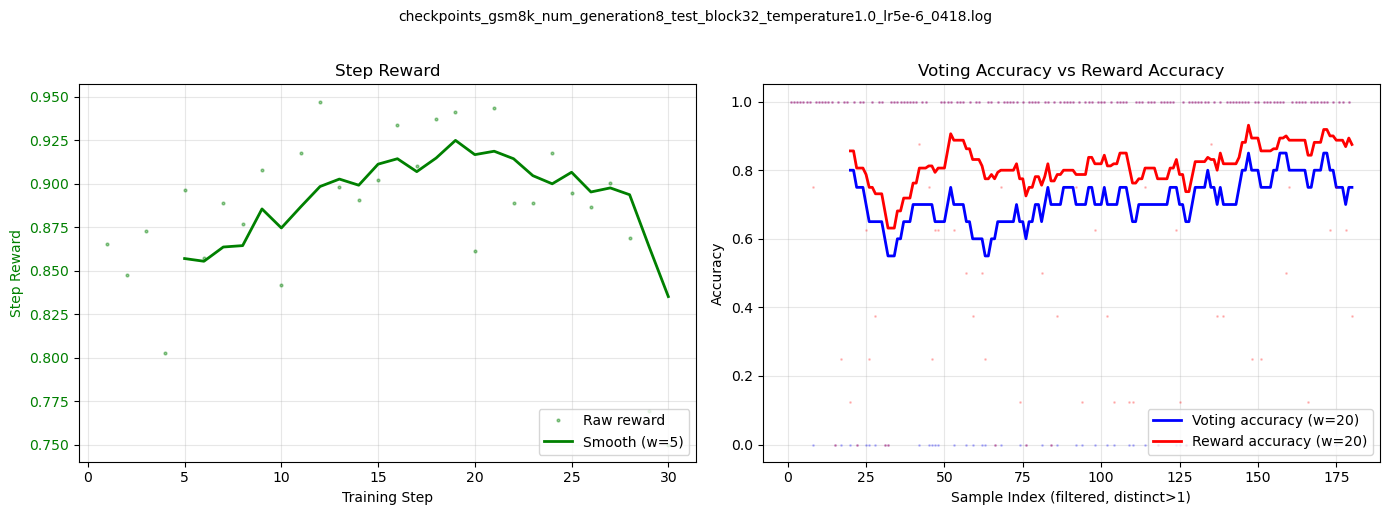

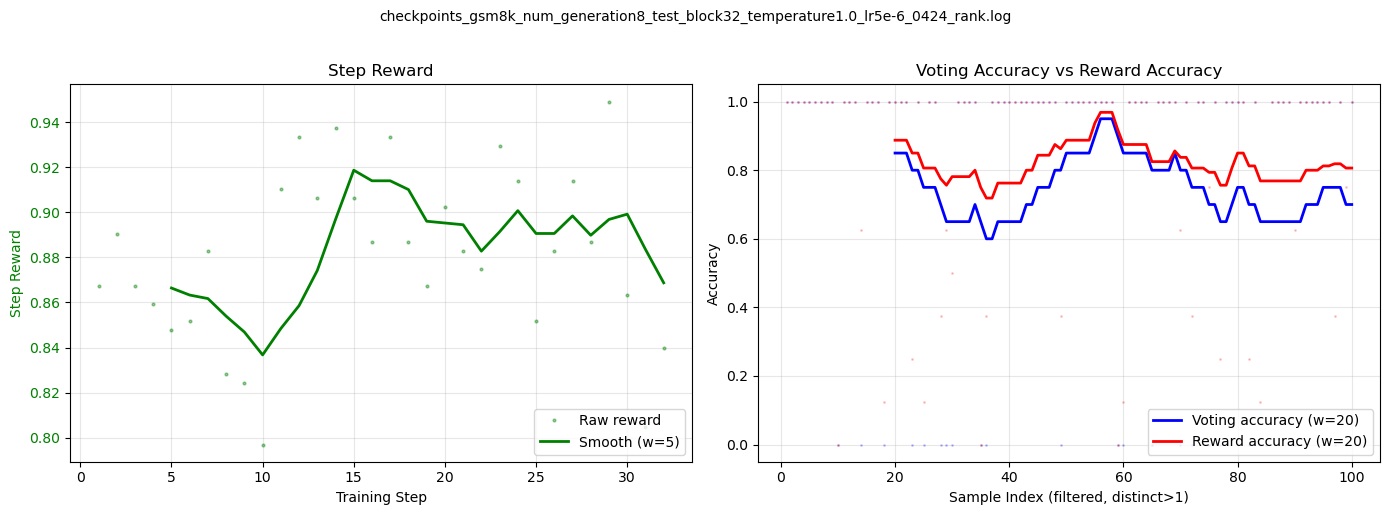

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
matplotlib.rcParams['axes.unicode_minus'] = False


def moving_average(data, window=10):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')


def parse_diversity_line(line):
    try:
        parts = line.strip().split('diversity|')[1].split('|')
        data = {}
        for part in parts:
            part = part.strip()
            if ': ' in part:                        # ← 改成 ': ' 不是 '='
                k, v = part.split(': ', 1)          # ← 改这里
                data[k.strip()] = v.strip()

        answers_str = data.get('extracted_answers', '[]')
        answers = [a.strip().strip("'\"") for a in answers_str.strip('[]').split(',') if a.strip()]

        return {
            'distinct_answer_num': int(data.get('distinct_answer_num', 0)),
            'best_is_correct': float(data.get('best_is_correct', 0)),
            'majority_answer': data.get('majority_answer', ''),
            'ground_truth': data.get('ground_truth_answer', ''),  # ← 也顺手改掉
            'extracted_answers': answers,
        }
    except Exception:
        return None


def parse_step_rewards(log_file):
    rewards = []
    grads = []
    pattern = re.compile(r'\[Step \d+/\d+\] reward=([\d.]+), grad=([\d.]+)')
    with open(log_file, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards.append(float(m.group(1)))
                grads.append(float(m.group(2)))
    return rewards, grads


def plot_voting_and_reward_acc_per_file(log_files, save_dir=None, smooth_window=10):
    def auto_ylim(data, margin=0.05):
        lo, hi = min(data), max(data)
        span = hi - lo if hi > lo else 0.1
        return lo - span * margin, hi + span * margin

    for log_file in log_files:
        data_list = []
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)

        step_rewards, step_grads = parse_step_rewards(log_file)

        if not data_list and not step_rewards:
            print(f"No data in {log_file}")
            continue

        voting_acc_list = []
        reward_acc_list = []

        for idx, data in enumerate(data_list):
            # 过滤所有 rollout 结果相同的样本
            if data['distinct_answer_num'] <= 1:
                continue

            voting_acc_list.append(data['best_is_correct'])

            if data['majority_answer'] and data['ground_truth']:
                answers = data['extracted_answers']
                majority = data['majority_answer']
                truth = data['ground_truth']
                tp = fp = tn = fn = 0
                for ans in answers:
                    est_reward = 1 if ans == majority else 0
                    true_reward = 1 if ans == truth else 0
                    if est_reward == 1 and true_reward == 1:
                        tp += 1
                    elif est_reward == 1 and true_reward == 0:
                        fp += 1
                    elif est_reward == 0 and true_reward == 0:
                        tn += 1
                    elif est_reward == 0 and true_reward == 1:
                        fn += 1
                total = tp + fp + tn + fn
                reward_acc_list.append((tp + tn) / total if total > 0 else 0)
            else:
                reward_acc_list.append(0)

        has_diversity = len(voting_acc_list) > 0
        has_steps = len(step_rewards) > 0

        # 布局：左侧 step reward + voting accuracy 合并一张图，右侧 reward accuracy
        # 更简洁：左图 = step reward, 右图 = voting accuracy + reward accuracy 双指标
        n_cols = (1 if has_steps else 0) + (1 if has_diversity else 0)
        if n_cols == 0:
            print(f"No plottable data in {log_file}")
            continue

        fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 5))
        if n_cols == 1:
            axes = [axes]

        fname = Path(log_file).name
        ax_idx = 0

        # 左图：step reward
        if has_steps:
            ax_reward = axes[ax_idx]
            x_steps = np.arange(1, len(step_rewards) + 1)
            ax_reward.plot(x_steps, step_rewards, 'g.', alpha=0.4, markersize=4, label='Raw reward')
            if len(step_rewards) >= smooth_window:
                reward_smooth_steps = moving_average(step_rewards, smooth_window)
                x_smooth_steps = x_steps[smooth_window - 1:]
                ax_reward.plot(x_smooth_steps, reward_smooth_steps, 'g-', linewidth=2,
                               label=f'Smooth (w={smooth_window})')
            ax_reward.set_xlabel('Training Step')
            ax_reward.set_ylabel('Step Reward', color='g')
            ax_reward.tick_params(axis='y', labelcolor='g')
            ax_reward.set_title('Step Reward')
            ax_reward.set_ylim(*auto_ylim(step_rewards))
            ax_reward.legend(loc='lower right')
            ax_reward.grid(True, alpha=0.3)
            ax_idx += 1

        # 右图：voting accuracy + reward accuracy（两条线一起）
        new_smooth_window = 20
        if has_diversity:
            ax_acc = axes[ax_idx]
            x_raw = np.arange(1, len(voting_acc_list) + 1)
            if len(voting_acc_list) >= new_smooth_window:
                voting_smooth = moving_average(voting_acc_list, new_smooth_window)
                reward_smooth = moving_average(reward_acc_list, new_smooth_window)
                x_smooth = x_raw[new_smooth_window - 1:]
            else:
                voting_smooth = voting_acc_list
                reward_smooth = reward_acc_list
                x_smooth = x_raw

            ax_acc.plot(x_smooth, voting_smooth, 'b-', linewidth=2,
                        label=f'Voting accuracy (w={new_smooth_window})')
            ax_acc.plot(x_smooth, reward_smooth, 'r-', linewidth=2,
                        label=f'Reward accuracy (w={new_smooth_window})')
            # raw 散点
            ax_acc.plot(x_raw, voting_acc_list, 'b.', alpha=0.2, markersize=2)
            ax_acc.plot(x_raw, reward_acc_list, 'r.', alpha=0.2, markersize=2)

            ax_acc.set_xlabel('Sample Index (filtered, distinct>1)')
            ax_acc.set_ylabel('Accuracy')
            ax_acc.set_title('Voting Accuracy vs Reward Accuracy')
            combined = list(voting_acc_list) + list(reward_acc_list)
            ax_acc.set_ylim(*auto_ylim(combined))
            ax_acc.legend(loc='lower right')
            ax_acc.grid(True, alpha=0.3)

        plt.suptitle(fname, fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()
        plt.close()


log_files = [
    "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0418.log",
    "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log",
]
plot_voting_and_reward_acc_per_file(log_files, save_dir="plots/", smooth_window=5)

Extracted 371 diversity entries from logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Extracted 257 diversity entries from logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log


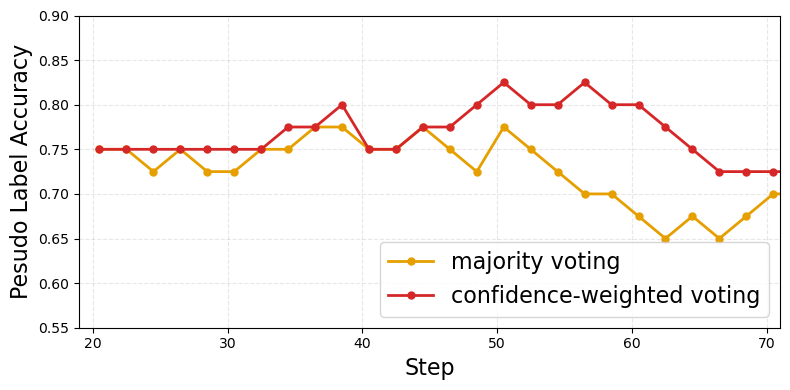

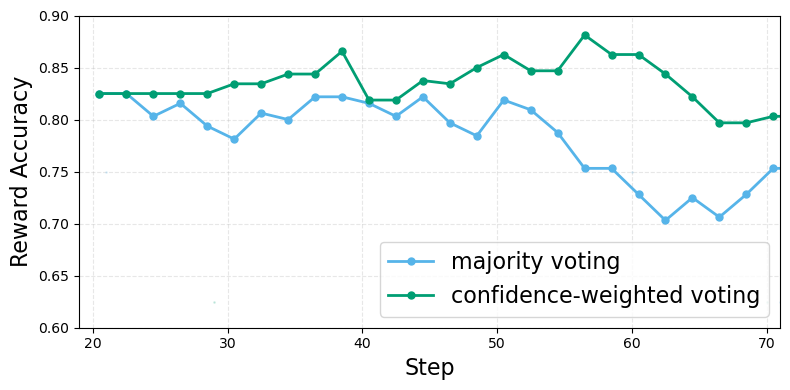


统计信息:
checkpoints_gsm8k_num_generation8_test_block32_0415: Voting=0.7554±0.4299, Reward=0.8273±0.3259
checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank: Voting=0.7600±0.4271, Reward=0.8363±0.3156


In [38]:
def compare_two_logs(log_file1, log_file2, save_dir=None, window_size=40, step_size=3):
    """
    对比两个日志文件的voting accuracy和reward accuracy
    
    Args:
        log_file1: 第一个日志文件路径
        log_file2: 第二个日志文件路径
        save_dir: 保存图片的目录
        window_size: 平滑窗口大小
        step_size: 滑动步长
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
    
    def extract_data(log_file):
        data_list = []
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
        print(f"Extracted {len(data_list)} diversity entries from {log_file}")
        voting_acc_list = []
        reward_acc_list = []
        
        for data in data_list:
            if data['distinct_answer_num'] <= 1:
                continue
            voting_acc_list.append(data['best_is_correct'])
            
            if data['majority_answer'] and data['ground_truth']:
                answers = data['extracted_answers']
                majority = data['majority_answer']
                truth = data['ground_truth']
                tp = fp = tn = fn = 0
                for ans in answers:
                    est_reward = 1 if ans == majority else 0
                    true_reward = 1 if ans == truth else 0
                    if est_reward == 1 and true_reward == 1:
                        tp += 1
                    elif est_reward == 1 and true_reward == 0:
                        fp += 1
                    elif est_reward == 0 and true_reward == 0:
                        tn += 1
                    elif est_reward == 0 and true_reward == 1:
                        fn += 1
                total = tp + fp + tn + fn
                reward_acc_list.append((tp + tn) / total if total > 0 else 0)
            else:
                reward_acc_list.append(0)
        
        return voting_acc_list, reward_acc_list
    
    def sliding_window_avg(data, window, step):
        """滑动窗口平均，步长可调"""
        if len(data) < window:
            return data, np.arange(1, len(data) + 1)
        
        smoothed = []
        x_positions = []
        
        for start in range(0, len(data) - window + 1, step):
            end = start + window
            smoothed.append(np.mean(data[start:end]))
            x_positions.append((start + end) / 2 + 0.5)
        
        return smoothed, x_positions
    
    # 提取数据
    voting1, reward1 = extract_data(log_file1)
    voting2, reward2 = extract_data(log_file2)
    
    if not voting1 and not voting2:
        print("两个文件都没有有效数据")
        return
    
    # 创建两张图
    fig1, ax1 = plt.subplots(figsize=(8, 4))
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    
    name1 = Path(log_file1).stem
    name2 = Path(log_file2).stem
    
    # 四个颜色：橙色、蓝色、绿色、红色
    color_voting1 = '#E69F00'  # 橙色 - majority voting
    color_voting2 = '#d62728'  # 蓝色 - confidence-weighted voting
    color_reward1 = '#56B4E9'  # 绿色 - majority voting reward
    color_reward2 = '#009E73'  # 红色 - confidence-weighted voting reward
    
    # 图1: Voting Accuracy
    if voting1:
        smooth1, x1 = sliding_window_avg(voting1, window_size, step_size)
        ax1.plot(x1, smooth1, 'o-', color=color_voting1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax1.plot(np.arange(1, len(voting1)+1), voting1, '.', color=color_voting1, alpha=0.15, markersize=2)
    
    if voting2:
        smooth2, x2 = sliding_window_avg(voting2, window_size, step_size)
        ax1.plot(x2, smooth2, 'o-', color=color_voting2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax1.plot(np.arange(1, len(voting2)+1), voting2, '.', color=color_voting2, alpha=0.15, markersize=2)
    
    ax1.set_xlabel('Step', fontsize=16)
    ax1.set_ylabel('Pesudo Label Accuracy', fontsize=16)
    ax1.set_xlim(19, 71)
    ax1.set_ylim(0.55, 0.9)
    ax1.legend(loc='lower right', fontsize=16)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 图2: Reward Accuracy
    if reward1:
        smooth1, x1 = sliding_window_avg(reward1, window_size, step_size)
        ax2.plot(x1, smooth1, 'o-', color=color_reward1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax2.plot(np.arange(1, len(reward1)+1), reward1, '.', color=color_reward1, alpha=0.15, markersize=2)
    
    if reward2:
        smooth2, x2 = sliding_window_avg(reward2, window_size, step_size)
        ax2.plot(x2, smooth2, 'o-', color=color_reward2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax2.plot(np.arange(1, len(reward2)+1), reward2, '.', color=color_reward2, alpha=0.15, markersize=2)
    
    ax2.set_xlabel('Step', fontsize=16)
    ax2.set_ylabel('Reward Accuracy', fontsize=16)
    ax2.set_xlim(19, 71)
    ax2.set_ylim(0.6, 0.9)
    ax2.legend(loc='lower right', fontsize=16)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    fig1.tight_layout()
    fig2.tight_layout()
    
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close('all')
    
    # 打印统计
    print("\n" + "="*60)
    print("统计信息:")
    print("="*60)
    if voting1:
        print(f"{name1}: Voting={np.mean(voting1):.4f}±{np.std(voting1):.4f}, Reward={np.mean(reward1):.4f}±{np.std(reward1):.4f}")
    if voting2:
        print(f"{name2}: Voting={np.mean(voting2):.4f}±{np.std(voting2):.4f}, Reward={np.mean(reward2):.4f}±{np.std(reward2):.4f}")


# 使用
log1 = "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log"
log2 = "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log"

compare_two_logs(log1, log2, save_dir="figures", window_size=40, step_size=2)

In [ ]:
colors = {'file1': {'voting': '#1f77b4', 'reward': '#ff7f0e'},
              'file2': {'voting': '#2ca02c', 'reward': '#d62728'}}